In [1]:
%pip install \
  "numpy==1.26.4" \
  "onnx==1.16.0" \
  "onnxruntime==1.17.0" \
  "onnxruntime-tools==1.7.0" \
  "opencv-python-headless==4.11.0.86" \
  "matplotlib==3.8.4"


Note: you may need to restart the kernel to use updated packages.


In [2]:
import onnx

# model_q4f16.onnx
model = onnx.load("../../checkpoints/model_q4f16.onnx")
ops = set([node.op_type for node in model.graph.node])
print("model_q4f16.onnx")
print(ops)

# model_uint8.onnx
model = onnx.load("../../checkpoints/model_uint8.onnx")
ops = set([node.op_type for node in model.graph.node])
print("model_uint8.onnx")
print(ops)

model_q4f16.onnx
{'MatMulNBits', 'Squeeze', 'Div', 'Shape', 'Mul', 'Pow', 'If', 'Slice', 'Add', 'Expand', 'ReduceMean', 'Split', 'Erf', 'Sqrt', 'Unsqueeze', 'Sub', 'Concat', 'Tan', 'Where', 'Softmax', 'Transpose', 'Clip', 'Reciprocal', 'Conv', 'Relu', 'MatMul', 'Gather', 'Equal', 'ConvTranspose', 'Resize', 'Reshape', 'Cast'}
model_uint8.onnx
{'Squeeze', 'Div', 'Shape', 'Mul', 'MatMulInteger', 'Pow', 'DynamicQuantizeLinear', 'If', 'Slice', 'ConvInteger', 'Add', 'Expand', 'ReduceMean', 'Split', 'Erf', 'Sqrt', 'Unsqueeze', 'Sub', 'Concat', 'Tan', 'Where', 'Softmax', 'Transpose', 'Clip', 'Reciprocal', 'Relu', 'MatMul', 'Gather', 'Equal', 'ConvTranspose', 'Resize', 'Reshape', 'Cast'}


In [3]:
import onnxruntime as ort

sess = ort.InferenceSession("../../checkpoints/model_uint8.onnx", providers=["CPUExecutionProvider"])

print("=== Inputs ===")
for i in sess.get_inputs():
    print(i.name, i.shape, i.type)

print("=== Outputs ===")
for o in sess.get_outputs():
    print(o.name, o.shape, o.type)


=== Inputs ===
pixel_values ['batch_size', 'num_channels', 'height', 'width'] tensor(float)
=== Outputs ===
predicted_depth ['batch_size', 'height', 'width'] tensor(float)
focallength_px ['batch_size', 'Reshapefocallength_px_dim_1'] tensor(float)


raw depth_pred shape: (1, 320, 320)
focal length px: [[551.5667]]
depth_map shape after squeeze: (320, 320)
Depth range: min = 9.186 m, max = 17.244 m


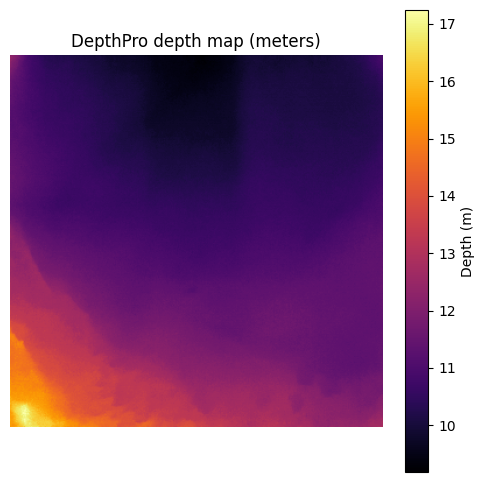

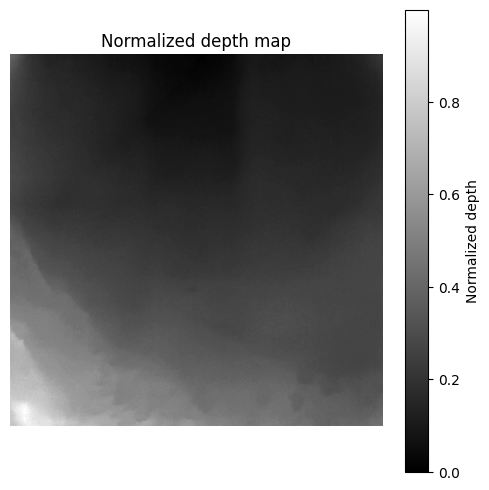

In [7]:
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt

# 1. 读图 (BGR -> RGB)
img = cv2.imread("test2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. resize（先用 1024x1024 之类的，后面根据实际 input shape 调整）
H, W = 320, 320
img = cv2.resize(img, (W, H), interpolation=cv2.INTER_LINEAR)

# 3. 转 float + 归一化
img = img.astype(np.float32) / 255.0
img = (img - 0.5) / 0.5   # mean=0.5, std=0.5

# 4. HWC -> NCHW
img = np.transpose(img, (2, 0, 1))      # [3, H, W]
img = np.expand_dims(img, 0)           # [1, 3, H, W]

# 5. 建 Session（用 uint8 的这个模型）
sess = ort.InferenceSession("../../checkpoints/model_uint8.onnx",
                            providers=["CPUExecutionProvider"])

inp = sess.get_inputs()[0]
out_depth, out_focal = sess.get_outputs()

feeds = {inp.name: img}

depth_pred, focal_pred = sess.run([out_depth.name, out_focal.name], feeds)

print("raw depth_pred shape:", depth_pred.shape)
print("focal length px:", focal_pred)

# 6. 处理深度结果：去掉多余维度 -> [H, W]
depth_map = np.squeeze(depth_pred)  # 支持 [1,1,H,W] / [1,H,W] / [H,W] 都统一搞成 [H,W]

print("depth_map shape after squeeze:", depth_map.shape)

# 7. 计算深度范围（单位：米）
# DepthPro 的输出本身就是 metric depth（meters）
d_min = float(np.nanmin(depth_map))
d_max = float(np.nanmax(depth_map))
print(f"Depth range: min = {d_min:.3f} m, max = {d_max:.3f} m")

# 8. 可视化：直接用真实深度做伪彩色显示
plt.figure(figsize=(6, 6))
im = plt.imshow(depth_map, cmap="inferno")
plt.colorbar(im, label="Depth (m)")
plt.axis("off")
plt.title("DepthPro depth map (meters)")
plt.show()

# 可选：再画一张归一化后的（便于看对比度）
norm = (depth_map - d_min) / (d_max - d_min + 1e-6)
plt.figure(figsize=(6, 6))
im2 = plt.imshow(norm, cmap="gray")
plt.colorbar(im2, label="Normalized depth")
plt.axis("off")
plt.title("Normalized depth map")
plt.show()


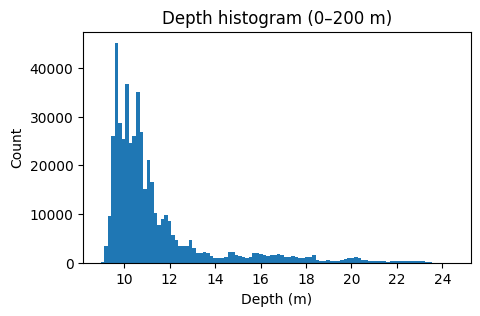

In [5]:
depth_map = np.squeeze(depth_pred)

valid = depth_map[np.isfinite(depth_map)]
# 只看 0~200m 以内，避免 10000 那种把直方图拉爆
valid_clip = valid[(valid > 0) & (valid < 200)]

plt.figure(figsize=(5, 3))
plt.hist(valid_clip, bins=100)
plt.xlabel("Depth (m)")
plt.ylabel("Count")
plt.title("Depth histogram (0–200 m)")
plt.show()


Depth (for visualization) vmin=9.314 m, vmax=21.112 m


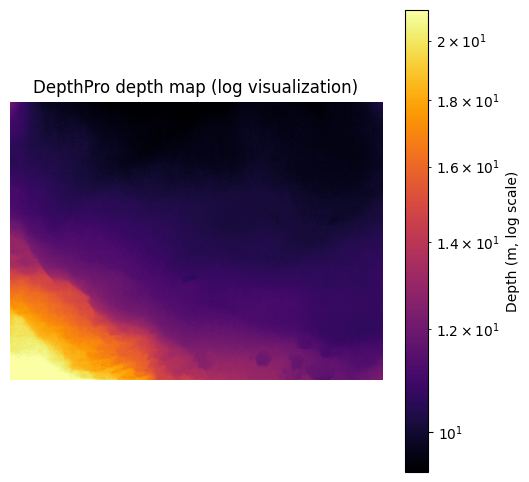

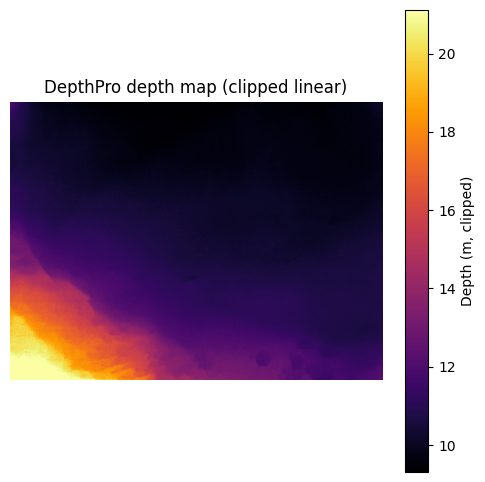

Raw valid depth range (after basic filtering): min = 8.974 m, max = 24.467 m


In [6]:
from matplotlib.colors import LogNorm

depth_map = np.squeeze(depth_pred)

# 1. 过滤掉明显的“垃圾值”：<=0 或 超大值（比如 > 2000m）
valid = depth_map[np.isfinite(depth_map)]
valid = valid[(valid > 0) & (valid < 2000)]

# 2. 用分位数决定可视化范围（比如 1%~99%）
vmin, vmax = np.percentile(valid, [1, 99])
print(f"Depth (for visualization) vmin={vmin:.3f} m, vmax={vmax:.3f} m")

# 3. 用 LogNorm 显示（对人眼友好）
plt.figure(figsize=(6, 6))
im = plt.imshow(
    depth_map,
    cmap="inferno",
    norm=LogNorm(vmin=max(vmin, 1e-3), vmax=vmax)  # 确保 vmin>0
)
plt.colorbar(im, label="Depth (m, log scale)")
plt.axis("off")
plt.title("DepthPro depth map (log visualization)")
plt.show()

# 4. 如果你还是想要“线性但去掉远平面”的版本，也可以再画一张：
vis_lin = np.clip(depth_map, vmin, vmax)
plt.figure(figsize=(6, 6))
im2 = plt.imshow(vis_lin, cmap="inferno")
plt.colorbar(im2, label="Depth (m, clipped)")
plt.axis("off")
plt.title("DepthPro depth map (clipped linear)")
plt.show()

# 5. 打印一下原始的真实范围（米），你之前那句也可以保留
d_min = float(np.nanmin(valid))
d_max = float(np.nanmax(valid))
print(f"Raw valid depth range (after basic filtering): min = {d_min:.3f} m, max = {d_max:.3f} m")
